# Shadow Tomography: Simulation + Hardware (Tuna-17)
Merged pipeline: simulated feedback-shadow on a 3-qubit cluster state, then hardware run on Quantum Inspire Tuna-17.

In [ ]:
! pip install --quiet --upgrade qiskit-aer qiskit-quantuminspire

In [1]:
import subprocess, sys, os, itertools, pickle
from pathlib import Path
from typing import List, Tuple, Dict
from collections import Counter
from functools import reduce

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

repo_root = os.path.abspath('../..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from shadow_gym.src.quantum_environment import QuantumEnvironment
from shadow_gym.src.shadow_processor import ShadowProcessor
print('Imports OK')

Imports OK


## 1 — Hardware Connection & Qubit Layout

In [2]:
subprocess.run(['qi', 'login', 'https://api.quantum-inspire.com'], check=False)

from qiskit_quantuminspire.qi_provider import QIProvider
provider = QIProvider()
backend  = provider.get_backend('Tuna-17')
print(f'Connected to: {backend.name}  ({backend.num_qubits} qubits)')

Please continue logging in by opening: https://auth.quantum-inspire.com/activate?user_code=NVFS-HTZX in your browser
If promped to verify a code, please confirm it is as follows: NVFS-HTZX
Login successful!
Using member ID 111
Connected to: Tuna-17  (17 qubits)


In [5]:
DATA_QUBITS   = [5, 8, 11]
CLUSTER_EDGES = [(5, 8), (8, 11)]
ANCILLA_MAP: Dict[int, Tuple[int,int]] = {5: (2, 9), 8: (4, 12), 11: (7, 14)}
N_DATA    = len(DATA_QUBITS)
N_SHADOWS = 1
SHOTS     = 10000

TUNA_POS = {
    0:(0,2), 1:(1,2), 2:(2,2), 3:(3,2), 4:(4,2),
    5:(0,1), 6:(1,1), 7:(2,1), 8:(3,1), 9:(4,1),
    10:(0,0),11:(1,0),12:(2,0),13:(3,0),14:(4,0),
    15:(5,2),16:(5,1),
}



## 2 — Ideal 3-Qubit Cluster State (Simulation)

Ideal 3-qubit cluster state | purity=1.000000


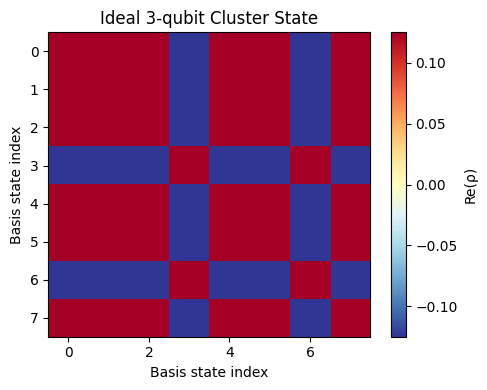

In [6]:
n_data = 3
env = QuantumEnvironment(n_data=n_data)
sv_ideal = env.prepare_cluster_state(depolarizing_p=0.0)
rho_ideal = env.rho_true

print(f'Ideal {n_data}-qubit cluster state | purity={np.real(np.trace(rho_ideal @ rho_ideal)):.6f}')

plt.figure(figsize=(5, 4))
plt.imshow(np.real(rho_ideal), cmap='RdYlBu_r', aspect='auto')
plt.colorbar(label='Re(ρ)')
plt.title(f'Ideal {n_data}-qubit Cluster State')
plt.xlabel('Basis state index'); plt.ylabel('Basis state index')
plt.tight_layout(); plt.show()

## 3 — Simulate Feedback-Shadow Measurements

In [7]:
def softmax_to_angles(px: float, py: float, pz: float) -> Tuple[float, float]:
    total = px + py + pz
    px, py, pz = px/total, py/total, pz/total
    p2 = py
    p1 = px / (px + pz + 1e-12)
    theta1 = 2.0 * np.arcsin(np.sqrt(np.clip(p1, 0, 1)))
    theta2 = 2.0 * np.arcsin(np.sqrt(np.clip(p2, 0, 1)))
    return theta1, theta2

theta1, theta2 = softmax_to_angles(1/3, 1/3, 1/3)
print(f'Uniform prior: θ1={np.degrees(theta1):.1f}°, θ2={np.degrees(theta2):.1f}°')

Uniform prior: θ1=90.0°, θ2=70.5°


In [8]:
def simulate_feedback_shadows(sv, n_qubits, theta1, theta2, n_shots=5000):
    from shadow_gym.src.utils import kron_n
    from shadow_gym.src.quantum_environment import QND_UNITARIES, QND_BASIS_LABELS
    p1 = np.sin(theta1/2) ** 2
    p2 = np.sin(theta2/2) ** 2
    results = []
    for shot in range(n_shots):
        ancilla_pairs = [
            (int(np.random.random() < p1), int(np.random.random() < p2))
            for _ in range(n_qubits)
        ]
        basis_labels = [QND_BASIS_LABELS[pair] for pair in ancilla_pairs]
        unitaries    = [QND_UNITARIES[pair]    for pair in ancilla_pairs]
        U_full = kron_n(*unitaries)
        sv_rot = U_full @ sv
        probs  = np.abs(sv_rot) ** 2
        idx    = np.random.choice(len(sv), p=probs)
        outcomes = [(idx >> (n_qubits - 1 - i)) & 1 for i in range(n_qubits)]
        results.append((basis_labels, outcomes))
    return results

print('Simulating 10 000 feedback-shadow shots...')
feedback_shadows = simulate_feedback_shadows(sv_ideal, n_data, theta1, theta2, n_shots=10000)
print(f'Done — {len(feedback_shadows)} shots')

Simulating 10 000 feedback-shadow shots...
Done — 10000 shots


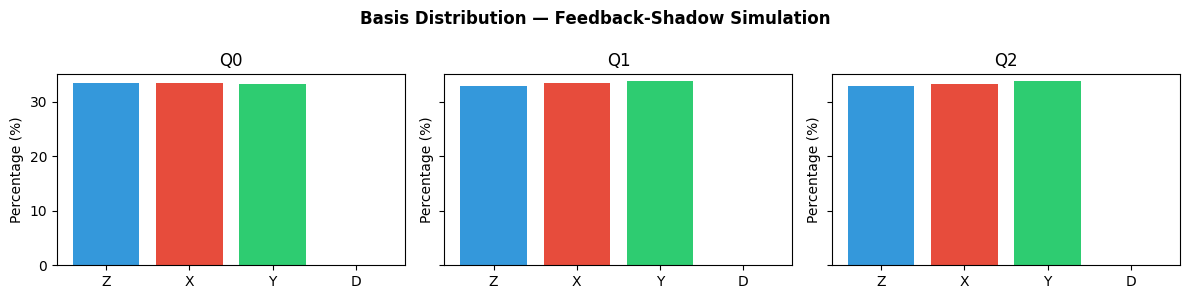

In [9]:
basis_counts = [Counter() for _ in range(n_data)]
for basis, _ in feedback_shadows:
    for i, b in enumerate(basis):
        basis_counts[i][b] += 1

fig, axes = plt.subplots(1, n_data, figsize=(12, 3), sharey=True)
basis_order = ['Z', 'X', 'Y', 'D']
colors = {'Z': '#3498db', 'X': '#e74c3c', 'Y': '#2ecc71', 'D': '#f39c12'}
for i, (ax, counts) in enumerate(zip(axes, basis_counts)):
    heights = [counts.get(b, 0) for b in basis_order]
    total = sum(heights)
    pcts = [100 * h / total for h in heights]
    ax.bar(basis_order, pcts, color=[colors[b] for b in basis_order])
    ax.set_ylabel('Percentage (%)'); ax.set_title(f'Q{i}'); ax.set_ylim(0, 35)
fig.suptitle('Basis Distribution — Feedback-Shadow Simulation', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 4 — Simulation: Density Matrix Convergence

     100 shots  fidelity=0.4437
     250 shots  fidelity=0.5698
    1000 shots  fidelity=0.7379
   10000 shots  fidelity=0.8972


/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_64774/3593172764.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


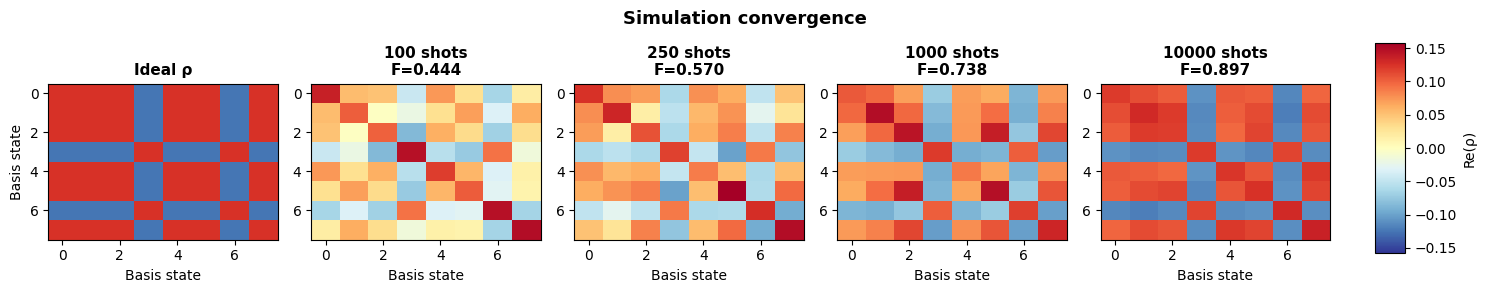

In [10]:
processor = ShadowProcessor(n_qubits=n_data)
shot_counts_sim = [100, 250, 1000, 10000]
rho_recons_sim  = []
fids_sim        = []

for n_shots in shot_counts_sim:
    rho = processor.reconstruct(feedback_shadows[:n_shots], project=True, regularization=0.01)
    fid = np.real(np.trace(rho @ rho_ideal))
    rho_recons_sim.append(rho); fids_sim.append(fid)
    print(f'  {n_shots:6d} shots  fidelity={fid:.4f}')

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
all_mats = [rho_ideal] + rho_recons_sim
max_abs  = max(np.max(np.abs(np.real(m))) for m in all_mats)
vmin, vmax = -max_abs, max_abs
for idx, (mat, ax) in enumerate(zip(all_mats, axes)):
    im = ax.imshow(np.real(mat), cmap='RdYlBu_r', aspect='auto', vmin=vmin, vmax=vmax)
    title = 'Ideal ρ' if idx == 0 else f'{shot_counts_sim[idx-1]} shots\nF={fids_sim[idx-1]:.3f}'
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Basis state')
    if idx == 0: ax.set_ylabel('Basis state')
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax).set_label('Re(ρ)', fontsize=10)
plt.suptitle('Simulation convergence', fontsize=13, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig('shadow_convergence_sim.png', dpi=300)
plt.show()

## 5 — Bootstrap Convergence Metrics (Simulation)

In [11]:
def kron_n(*ops):
    return reduce(lambda a, b: np.kron(a, b), ops)

I = np.eye(2, dtype=complex)
X = np.array([[0,1],[1,0]], dtype=complex)
Y = np.array([[0,-1j],[1j,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)

K1 = kron_n(X, Z, I)
K2 = kron_n(Z, X, Z)
K3 = kron_n(I, Z, X)
XXX = kron_n(X, X, X)

n_boot = 200
rng = np.random.default_rng(123)
regularization = 0.01
dim = 2 ** n_data
mixed = np.eye(dim, dtype=complex) / dim

def project_dm(rho):
    rho = (rho + rho.conj().T) / 2
    vals, vecs = np.linalg.eigh(rho)
    vals = np.maximum(vals, 0.0); vals /= vals.sum()
    return vecs @ np.diag(vals) @ vecs.conj().T

shot_counts_log = np.unique(np.logspace(2, 4, num=8, dtype=int)).tolist()
snapshots = [processor._snapshot(basis, outcome) for basis, outcome in feedback_shadows]

sim_fid_pt=[]; sim_fid_std=[]; sim_K1_pt=[]; sim_K1_std=[]
sim_K2_pt=[]; sim_K2_std=[]; sim_K3_pt=[]; sim_K3_std=[]
sim_XXX_pt=[]; sim_XXX_std=[]

for n_shots in shot_counts_log:
    rho_avg = sum(snapshots[:n_shots]) / float(n_shots)
    rho_reg = (1-regularization)*rho_avg + regularization*mixed
    rho_pt  = project_dm(rho_reg)
    sim_fid_pt.append(np.real(np.trace(rho_pt @ rho_ideal)))
    sim_K1_pt.append(np.real(np.trace(rho_pt @ K1)))
    sim_K2_pt.append(np.real(np.trace(rho_pt @ K2)))
    sim_K3_pt.append(np.real(np.trace(rho_pt @ K3)))
    sim_XXX_pt.append(np.real(np.trace(rho_pt @ XXX)))
    fid_s=[]; k1s=[]; k2s=[]; k3s=[]; xxxs=[]
    for _ in range(n_boot):
        idxs = rng.integers(0, len(snapshots), size=n_shots)
        r_b_avg = sum(snapshots[i] for i in idxs) / float(n_shots)
        r_b = project_dm((1-regularization)*r_b_avg + regularization*mixed)
        fid_s.append(np.real(np.trace(r_b @ rho_ideal)))
        k1s.append(np.real(np.trace(r_b @ K1)))
        k2s.append(np.real(np.trace(r_b @ K2)))
        k3s.append(np.real(np.trace(r_b @ K3)))
        xxxs.append(np.real(np.trace(r_b @ XXX)))
    sim_fid_std.append(np.std(fid_s, ddof=1))
    sim_K1_std.append(np.std(k1s, ddof=1)); sim_K2_std.append(np.std(k2s, ddof=1))
    sim_K3_std.append(np.std(k3s, ddof=1)); sim_XXX_std.append(np.std(xxxs, ddof=1))
    print(f'{n_shots:6d} shots: fid={sim_fid_pt[-1]:.4f} ± {sim_fid_std[-1]:.4f}')

out_dir = Path('data'); out_dir.mkdir(parents=True, exist_ok=True)
np.savez(out_dir/'mock_convergence_metrics.npz',
         shot_counts=np.array(shot_counts_log),
         fidelities=np.array(sim_fid_pt), fidelities_std=np.array(sim_fid_std),
         K1=np.array(sim_K1_pt), K1_std=np.array(sim_K1_std),
         K2=np.array(sim_K2_pt), K2_std=np.array(sim_K2_std),
         K3=np.array(sim_K3_pt), K3_std=np.array(sim_K3_std),
         XXX=np.array(sim_XXX_pt), XXX_std=np.array(sim_XXX_std))
print('Saved simulation metrics.')

   100 shots: fid=0.4437 ± 0.0555
   193 shots: fid=0.5679 ± 0.0506
   372 shots: fid=0.6132 ± 0.0367
   719 shots: fid=0.6911 ± 0.0336
  1389 shots: fid=0.7627 ± 0.0249
  2682 shots: fid=0.8124 ± 0.0221
  5179 shots: fid=0.8472 ± 0.0192
 10000 shots: fid=0.8972 ± 0.0131
Saved simulation metrics.


## 6 — Hardware Shadow Circuit & Job Submission

In [12]:
def prepare_cluster_state(qc: QuantumCircuit) -> None:
    for dq in DATA_QUBITS: qc.h(dq)
    for q1, q2 in CLUSTER_EDGES: qc.cz(q1, q2)

def build_shadow_circuit(theta1_per_qubit, theta2_per_qubit) -> QuantumCircuit:
    c_all = ClassicalRegister(N_DATA + 2*N_DATA, name='c_all')
    qc = QuantumCircuit(17, name='shadow'); qc.add_register(c_all)
    for i, dq in enumerate(DATA_QUBITS):
        a1, a2 = ANCILLA_MAP[dq]
        if theta1_per_qubit[i] != 0: qc.ry(theta1_per_qubit[i], a1)
        if theta2_per_qubit[i] != 0: qc.ry(theta2_per_qubit[i], a2)
    for i, dq in enumerate(DATA_QUBITS):
        a1, a2 = ANCILLA_MAP[dq]
        qc.measure(a1, c_all[N_DATA + 2*i])
        qc.measure(a2, c_all[N_DATA + 2*i + 1])
    prepare_cluster_state(qc)
    for i, dq in enumerate(DATA_QUBITS):
        a1, a2 = ANCILLA_MAP[dq]
        qc.cry(-np.pi/2, a1, dq)
        qc.crx( np.pi/2, a2, dq)
    for i, dq in enumerate(DATA_QUBITS):
        qc.measure(dq, c_all[i])
    return qc

th1_unif, th2_unif = softmax_to_angles(1/3, 1/3, 1/3)
shadow_circuits_raw = [build_shadow_circuit([th1_unif]*N_DATA, [th2_unif]*N_DATA)]
shadow_angles = [([th1_unif]*N_DATA, [th2_unif]*N_DATA)]
print(f'Built {len(shadow_circuits_raw)} shadow circuit(s), depth={shadow_circuits_raw[0].depth()}')

Built 1 shadow circuit(s), depth=6


/opt/anaconda3/lib/python3.12/site-packages/qiskit/visualization/circuit/matplotlib.py:270: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: /opt/anaconda3/lib/python3.12/site-packages/qiskit/visualization/circuit/styles/iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(


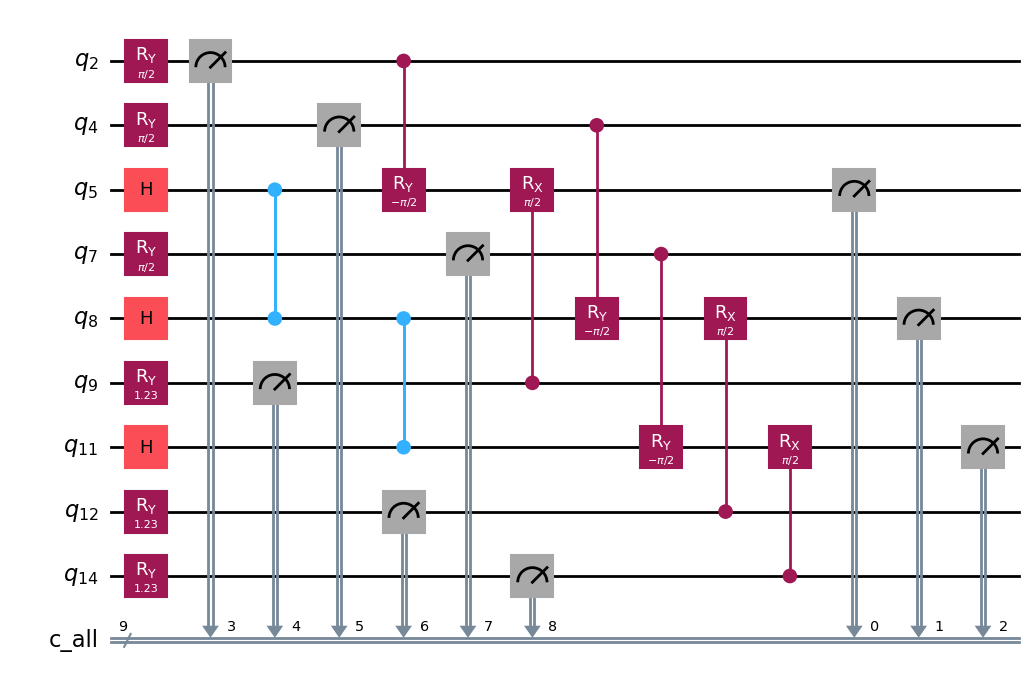

In [15]:
shadow_circuits_raw[0].draw(output='mpl', style='iqx', idle_wires=False)

In [16]:
shadow_circuits_tpld = transpile(shadow_circuits_raw, backend=backend, optimization_level=3)
job = backend.run(shadow_circuits_tpld, shots=SHOTS, memory=True)
print(f'Job submitted. ID: {job.job_id()}')

Job submitted. ID: 


In [17]:
result = job.result(timeout=6000)
all_memories = [result.get_memory(i) for i in range(N_SHADOWS)]

data_dir = Path('data'); data_dir.mkdir(parents=True, exist_ok=True)
out_path = data_dir / 'shadow_act1_batch.pkl'
with out_path.open('wb') as f:
    pickle.dump({'memories': all_memories, 'shadow_angles': shadow_angles,
                 'n_shadows': N_SHADOWS, 'shots': SHOTS,
                 'data_qubits': DATA_QUBITS, 'ancilla_map': ANCILLA_MAP,
                 'job_id': job.job_id()}, f)
print(f'Saved {sum(len(m) for m in all_memories)} shots → {out_path}')

Saved 10000 shots → data/shadow_act1_batch.pkl


## 7 — Decode Hardware Results

In [18]:
pkl_path = Path('data/shadow_act1_batch.pkl')
with pkl_path.open('rb') as f:
    payload = pickle.load(f)
all_memories = payload['memories']
shadow_angles = payload['shadow_angles']

ANCILLA_TO_BASIS = {(0,0):'Z', (1,0):'X', (0,1):'Y', (1,1):'Y'}

def decode_shot(bitstring: str) -> Tuple[List[str], List[int]]:
    bits = bitstring.strip().replace(' ', '')
    bits_rev = bits[::-1]
    c_data = bits_rev[:N_DATA]
    c_anc  = bits_rev[N_DATA:N_DATA + 2*N_DATA]
    basis_list, outcome_list = [], []
    for i in range(N_DATA):
        a1, a2 = int(c_anc[2*i]), int(c_anc[2*i+1])
        basis_list.append(ANCILLA_TO_BASIS[(a1, a2)])
        outcome_list.append(int(c_data[i]))
    return basis_list, outcome_list

shadow_buffer = [decode_shot(bs) for mem in all_memories for bs in mem]
print(f'Decoded {len(shadow_buffer)} shots')

Decoded 10000 shots


## 8 — Hardware Density Matrix Reconstruction & Convergence

     100 shots  fidelity=0.2721
     250 shots  fidelity=0.3208
    1000 shots  fidelity=0.5165
   10000 shots  fidelity=0.5729


/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_64774/4059049356.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


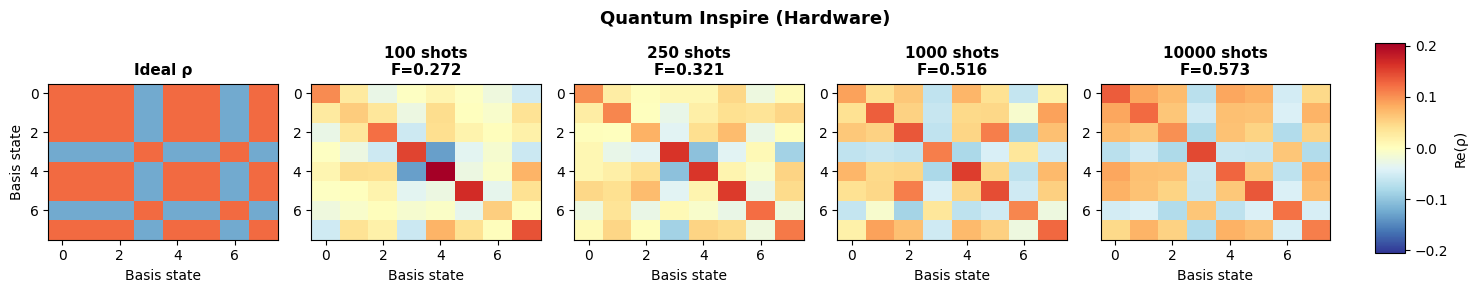

In [19]:
env_hw = QuantumEnvironment(n_data=N_DATA)
env_hw.prepare_cluster_state(depolarizing_p=0.0)
rho_ideal = env_hw.rho_true
processor_hw = ShadowProcessor(n_qubits=N_DATA)

shot_counts_hw = [100, 250, 1000, 10000]
rho_recons_hw  = []
fids_hw        = []

for n_shots in shot_counts_hw:
    rho = processor_hw.reconstruct(shadow_buffer[:n_shots], project=True, regularization=0.01)
    fid = np.real(np.trace(rho @ rho_ideal))
    rho_recons_hw.append(rho); fids_hw.append(fid)
    print(f'  {n_shots:6d} shots  fidelity={fid:.4f}')

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
all_mats = [rho_ideal] + rho_recons_hw
max_abs  = max(np.max(np.abs(np.real(m))) for m in all_mats)
vmin, vmax = -max_abs, max_abs
for idx, (mat, ax) in enumerate(zip(all_mats, axes)):
    im = ax.imshow(np.real(mat), cmap='RdYlBu_r', aspect='auto', vmin=vmin, vmax=vmax)
    title = 'Ideal ρ' if idx == 0 else f'{shot_counts_hw[idx-1]} shots\nF={fids_hw[idx-1]:.3f}'
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Basis state')
    if idx == 0: ax.set_ylabel('Basis state')
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax).set_label('Re(ρ)', fontsize=10)
plt.suptitle('Quantum Inspire (Hardware)', fontsize=13, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig('cluster_state_convergence_hardware.png', dpi=300)
plt.show()

## 9 — Hardware vs Simulation: Fidelity & Stabilizer Expectations

   100 shots: hw_fid=0.2721 ± 0.0548
   193 shots: hw_fid=0.2926 ± 0.0596
   372 shots: hw_fid=0.4167 ± 0.0439
   719 shots: hw_fid=0.5344 ± 0.0423
  1389 shots: hw_fid=0.5716 ± 0.0257
  2682 shots: hw_fid=0.5666 ± 0.0226
  5179 shots: hw_fid=0.5720 ± 0.0170
 10000 shots: hw_fid=0.5729 ± 0.0156


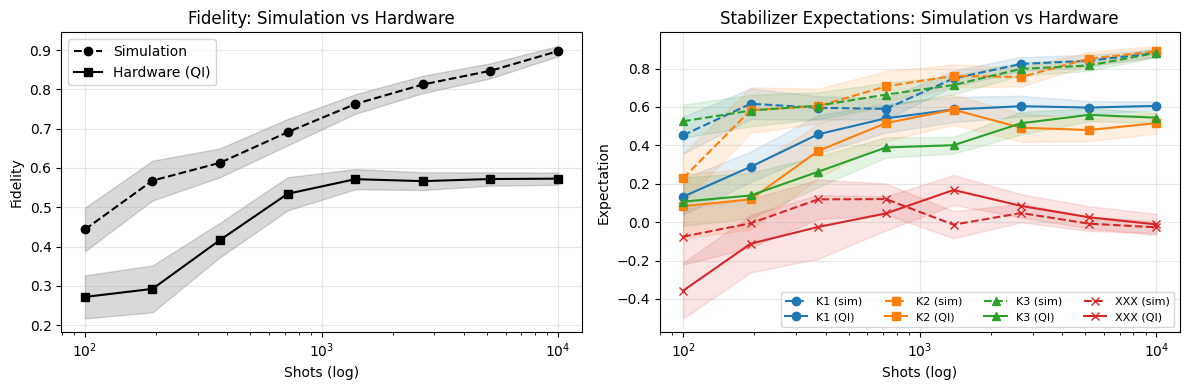

In [20]:
n_boot_hw = 20
rng_hw = np.random.default_rng(42)
sim_data = np.load('data/mock_convergence_metrics.npz')
sim_shots = np.array(sim_data['shot_counts'], dtype=int)

sim_fid_pt  = np.array(sim_data['fidelities'])
sim_fid_std = np.array(sim_data['fidelities_std'])
sim_K1_pt   = np.array(sim_data['K1']); sim_K1_std = np.array(sim_data['K1_std'])
sim_K2_pt   = np.array(sim_data['K2']); sim_K2_std = np.array(sim_data['K2_std'])
sim_K3_pt   = np.array(sim_data['K3']); sim_K3_std = np.array(sim_data['K3_std'])
sim_XXX_pt  = np.array(sim_data['XXX']); sim_XXX_std = np.array(sim_data['XXX_std'])

hw_fid_pt=[]; hw_K1_pt=[]; hw_K2_pt=[]; hw_K3_pt=[]; hw_XXX_pt=[]
hw_fid_std=[]; hw_K1_std=[]; hw_K2_std=[]; hw_K3_std=[]; hw_XXX_std=[]
max_hw = len(shadow_buffer)

for n_shots in sim_shots:
    rho_full = processor_hw.reconstruct(shadow_buffer[:n_shots], project=True, regularization=0.01)
    hw_fid_pt.append(np.real(np.trace(rho_full @ rho_ideal)))
    hw_K1_pt.append(np.real(np.trace(rho_full @ K1)))
    hw_K2_pt.append(np.real(np.trace(rho_full @ K2)))
    hw_K3_pt.append(np.real(np.trace(rho_full @ K3)))
    hw_XXX_pt.append(np.real(np.trace(rho_full @ XXX)))
    fid_s=[]; k1s=[]; k2s=[]; k3s=[]; xxxs=[]
    for _ in range(n_boot_hw):
        idxs = rng_hw.integers(0, max_hw, size=n_shots)
        r_b = processor_hw.reconstruct([shadow_buffer[i] for i in idxs], project=True, regularization=0.01)
        fid_s.append(np.real(np.trace(r_b @ rho_ideal)))
        k1s.append(np.real(np.trace(r_b @ K1))); k2s.append(np.real(np.trace(r_b @ K2)))
        k3s.append(np.real(np.trace(r_b @ K3))); xxxs.append(np.real(np.trace(r_b @ XXX)))
    hw_fid_std.append(np.std(fid_s, ddof=1))
    hw_K1_std.append(np.std(k1s, ddof=1)); hw_K2_std.append(np.std(k2s, ddof=1))
    hw_K3_std.append(np.std(k3s, ddof=1)); hw_XXX_std.append(np.std(xxxs, ddof=1))
    print(f'{n_shots:6d} shots: hw_fid={hw_fid_pt[-1]:.4f} ± {hw_fid_std[-1]:.4f}')

hw_fid_pt=np.array(hw_fid_pt); hw_fid_std=np.array(hw_fid_std)
hw_K1_pt=np.array(hw_K1_pt);   hw_K1_std=np.array(hw_K1_std)
hw_K2_pt=np.array(hw_K2_pt);   hw_K2_std=np.array(hw_K2_std)
hw_K3_pt=np.array(hw_K3_pt);   hw_K3_std=np.array(hw_K3_std)
hw_XXX_pt=np.array(hw_XXX_pt); hw_XXX_std=np.array(hw_XXX_std)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sim_shots, sim_fid_pt, '--o', color='k', label='Simulation')
axes[0].fill_between(sim_shots, sim_fid_pt - sim_fid_std, sim_fid_pt + sim_fid_std, color='k', alpha=0.15)
axes[0].plot(sim_shots, hw_fid_pt,  '-s',  color='k', label='Hardware (QI)')
axes[0].fill_between(sim_shots, hw_fid_pt - hw_fid_std, hw_fid_pt + hw_fid_std, color='k', alpha=0.15)
axes[0].set_xscale('log'); axes[0].set_xlabel('Shots (log)'); axes[0].set_ylabel('Fidelity')
axes[0].set_title('Fidelity: Simulation vs Hardware'); axes[0].grid(True, alpha=0.3); axes[0].legend()

for key, sim_pt, sim_s, hw_pt, hw_s, mk in [
    ('K1', sim_K1_pt, sim_K1_std, hw_K1_pt, hw_K1_std, 'o'),
    ('K2', sim_K2_pt, sim_K2_std, hw_K2_pt, hw_K2_std, 's'),
    ('K3', sim_K3_pt, sim_K3_std, hw_K3_pt, hw_K3_std, '^'),
    ('XXX', sim_XXX_pt, sim_XXX_std, hw_XXX_pt, hw_XXX_std, 'x'),
]:
    c = {'K1':'C0','K2':'C1','K3':'C2','XXX':'C3'}[key]
    axes[1].plot(sim_shots, sim_pt, f'--{mk}', color=c, label=f'{key} (sim)')
    axes[1].fill_between(sim_shots, sim_pt - sim_s, sim_pt + sim_s, color=c, alpha=0.12)
    axes[1].plot(sim_shots, hw_pt,  f'-{mk}',  color=c, label=f'{key} (QI)')
    axes[1].fill_between(sim_shots, hw_pt - hw_s,  hw_pt + hw_s,  color=c, alpha=0.12)
axes[1].set_xscale('log'); axes[1].set_xlabel('Shots (log)'); axes[1].set_ylabel('Expectation')
axes[1].set_title('Stabilizer Expectations: Simulation vs Hardware')
axes[1].grid(True, alpha=0.3); axes[1].legend(loc='best', ncol=4, fontsize=8)

plt.tight_layout()
plt.savefig('Convergence.png', dpi=200)
plt.show()